# WD-cGAN — Modulo 2: Training v21-minimal-corrected

Correzioni rispetto alla v20:

- DWT differenziabile in PyTorch: niente `detach().cpu().numpy()` nel forward della DWT.
- Rimozione di `Tanh()` finale dal generatore, per non schiacciare i picchi z-score.
- Nuova amplitude loss basata su distribuzione di `std` e PGA.
- Congelamento dei discriminatori durante lo step G.
- Test automatico `requires_grad` per verificare che la DWT resti nel grafo.

Nota: `N_EPOCHS = 50` è impostato per il primo test. Dopo verifica puoi riportarlo a 200.


In [3]:
!pip install -q pywavelets h5py tqdm


In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pywt
import h5py
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from scipy import signal as sp_signal
from itertools import combinations

BASE_DIR  = '/content/drive/MyDrive/WDcGAN'
DATA_DIR  = os.path.join(BASE_DIR, 'data')
CKPT_DIR  = os.path.join(BASE_DIR, 'checkpoints')
LOG_DIR   = os.path.join(BASE_DIR, 'logs')
HDF5_PATH = os.path.join(DATA_DIR, 'itaca_dataset.h5')
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(LOG_DIR,  exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Mounted at /content/drive
Device: cuda


In [5]:
VERSION       = 'v21_minimal_diffDWT_noTanh_ampdist_freezeD'
LATENT_DIM    = 400
N_SAMPLES     = 8000
N_EPOCHS      = 400    # PRIMA PROVA. Dopo verifica puoi riportare a 200.
BATCH_SIZE    = 16
LR            = 2e-4
BETA1         = 0.5
BETA2         = 0.999
DWT_WAVELET   = 'db4'
DWT_LEVEL     = 6
COND_DIM      = 16
LRELU_SLOPE   = 0.1
CKPT_EVERY    = 50
MW_MIN        = 5.0
MW_MAX        = 5.5
FS            = 200

# Loss weights
LAMBDA_FM     = 1.0
LAMBDA_ENV    = 2.0
LAMBDA_AMP    = 2.0    # nuova loss: std + PGA; non usare 5.0 subito
LAMBDA_PSD    = 0.5
LAMBDA_MS     = 0.5
PSD_TARGET    = -2.0

print(f'Versione: {VERSION}')
print(f'lambda_fm={LAMBDA_FM} lambda_env={LAMBDA_ENV} lambda_amp={LAMBDA_AMP}')
print(f'lambda_psd={LAMBDA_PSD} lambda_ms={LAMBDA_MS} psd_target={PSD_TARGET}')


Versione: v21_minimal_diffDWT_noTanh_ampdist_freezeD
lambda_fm=1.0 lambda_env=2.0 lambda_amp=2.0
lambda_psd=0.5 lambda_ms=0.5 psd_target=-2.0


In [6]:
with h5py.File(HDF5_PATH, 'r') as hf:
    raw_sigs = hf['signals_e'][:]
    raw_mags = hf['magnitudes'][:]

print(f'Record: {len(raw_sigs)} | Mw: {raw_mags.min():.2f}-{raw_mags.max():.2f}')

sigs_t = torch.tensor(raw_sigs, dtype=torch.float32).unsqueeze(1)
mags_t = torch.tensor(raw_mags, dtype=torch.float32)

dataset = TensorDataset(sigs_t, mags_t)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)


Record: 1879 | Mw: 5.00-5.47


In [7]:
# ============================================================
# Losses
# ============================================================

def compute_local_rms(sig, window_s=1.0, fs=200):
    win = int(window_s * fs)
    stride = max(1, win // 2)
    return torch.sqrt(F.avg_pool1d(sig**2, win, stride) + 1e-8)


def jennings_housner_shape_random(B, n_win, device):
    t        = torch.linspace(0, 1, n_win, device=device)
    onset_f  = torch.empty(B, device=device).uniform_(0.05, 0.30)
    ramp_f   = torch.empty(B, device=device).uniform_(0.03, 0.10)
    strong_f = torch.empty(B, device=device).uniform_(0.10, 0.35)
    c_vals   = torch.empty(B, device=device).uniform_(5.0, 15.0)

    ta_f = (onset_f + ramp_f).clamp(max=0.83)
    tb_f = (onset_f + strong_f).clamp(max=0.85)
    ta_f = torch.min(ta_f, tb_f - 0.02)

    t_exp = t.unsqueeze(0).expand(B, -1)
    env   = torch.zeros(B, n_win, device=device)

    mask1 = (t_exp >= onset_f.unsqueeze(1)) & (t_exp < ta_f.unsqueeze(1))
    denom = (ta_f - onset_f).clamp(min=1e-4).unsqueeze(1)
    env   = torch.where(mask1, ((t_exp - onset_f.unsqueeze(1)) / denom) ** 2, env)

    mask2 = (t_exp >= ta_f.unsqueeze(1)) & (t_exp < tb_f.unsqueeze(1))
    env   = torch.where(mask2, torch.ones_like(env), env)

    mask3 = t_exp >= tb_f.unsqueeze(1)
    env   = torch.where(
        mask3,
        torch.exp(-c_vals.unsqueeze(1) * (t_exp - tb_f.unsqueeze(1))),
        env
    )

    env_max = env.max(dim=1, keepdim=True)[0].clamp(min=1e-6)
    return (env / env_max).unsqueeze(1)


def envelope_shape_loss(sig_gen, mw_batch=None, fs=200, window_s=1.0):
    B, _, T = sig_gen.shape
    rms_gen = compute_local_rms(sig_gen, window_s, fs)
    n_win   = rms_gen.shape[2]

    rms_max  = rms_gen.max(dim=2, keepdim=True)[0].clamp(min=1e-6)
    rms_norm = rms_gen / rms_max

    jh = jennings_housner_shape_random(B, n_win, sig_gen.device)
    return F.mse_loss(rms_norm, jh)


def amplitude_distribution_loss(fake, real):
    """
    Loss di ampiezza più forte della vecchia soglia su std.

    Confronta le distribuzioni batch-wise di:
    - std del segnale
    - PGA = Peak Ground Acceleration = max(|a(t)|)

    Usare torch.sort rende il confronto indipendente dall'accoppiamento esatto
    real/fake dentro il batch.
    """
    fake = fake.squeeze(1)
    real = real.squeeze(1).detach()

    fake_std = fake.std(dim=1, unbiased=False)
    real_std = real.std(dim=1, unbiased=False)

    fake_pga = fake.abs().max(dim=1).values
    real_pga = real.abs().max(dim=1).values

    loss_std = F.l1_loss(torch.sort(fake_std).values, torch.sort(real_std).values)
    loss_pga = F.l1_loss(torch.sort(fake_pga).values, torch.sort(real_pga).values)

    return loss_std + 0.25 * loss_pga


def psd_slope_loss(sig_gen, fs=200, f_low=1.0, f_high=20.0, target=-2.0):
    B, _, T = sig_gen.shape

    sig_norm = sig_gen / sig_gen.std(dim=2, keepdim=True).clamp(min=1e-6)
    fft_mag  = torch.abs(torch.fft.rfft(sig_norm.squeeze(1), dim=1))
    freqs    = torch.fft.rfftfreq(T, d=1.0 / fs).to(sig_gen.device)

    mask = (freqs >= f_low) & (freqs <= f_high)
    if mask.sum() < 3:
        return torch.tensor(0.0, device=sig_gen.device)

    f_sel = freqs[mask]
    p_sel = (fft_mag[:, mask] ** 2).mean(0)

    log_f = torch.log10(f_sel)
    log_p = torch.log10(p_sel + 1e-12)

    slope = (log_p[-1] - log_p[0]) / (log_f[-1] - log_f[0] + 1e-6)
    return (slope - target) ** 2


def mode_seeking_loss(fake1, fake2, z1, z2, eps=1e-5):
    dist_x = torch.mean(torch.abs(fake1 - fake2))
    dist_z = torch.mean(torch.abs(z1 - z2))
    return 1.0 / (dist_x / (dist_z + eps) + eps)

print('Losses OK')


Losses OK


In [8]:
# ============================================================
# DWT differenziabile + classi modello
# ============================================================

class DWTBlock(nn.Module):
    """
    DWT differenziabile in PyTorch.

    Differenza fondamentale rispetto alla v20:
    - niente detach()
    - niente cpu().numpy()
    - niente pywt.wavedec() nel forward

    PyWavelets viene usato solo in __init__ per leggere i coefficienti
    dei filtri db4. Poi la trasformata è fatta con conv1d PyTorch.

    Output: [D1, D2, ..., D_level, A_level]
    """
    def __init__(self, wavelet='db4', level=6):
        super().__init__()
        self.wavelet = wavelet
        self.level = level

        w = pywt.Wavelet(wavelet)

        # torch.conv1d esegue cross-correlazione; invertiamo i filtri
        dec_lo = torch.tensor(w.dec_lo[::-1], dtype=torch.float32).view(1, 1, -1)
        dec_hi = torch.tensor(w.dec_hi[::-1], dtype=torch.float32).view(1, 1, -1)

        self.register_buffer('dec_lo', dec_lo)
        self.register_buffer('dec_hi', dec_hi)
        self.filter_len = len(w.dec_lo)

    def _analysis_step(self, x):
        B, C, T = x.shape
        if C != 1:
            raise ValueError(f'DWTBlock si aspetta C=1, ricevuto C={C}')

        k = self.filter_len

        # Lunghezza analoga alla modalità symmetric di PyWavelets:
        # floor((T + k - 1) / 2). Per T pari diventa (T+k-1)//2.
        target_len = (T + k - 1) // 2

        # Padding per ottenere target_len con stride=2.
        total_pad = max(0, 2 * (target_len - 1) - T + k)
        pad_left  = total_pad // 2
        pad_right = total_pad - pad_left

        x_pad = F.pad(x, (pad_left, pad_right), mode='reflect')

        lo_filter = self.dec_lo.to(device=x.device, dtype=x.dtype)
        hi_filter = self.dec_hi.to(device=x.device, dtype=x.dtype)

        approx = F.conv1d(x_pad, lo_filter, stride=2)
        detail = F.conv1d(x_pad, hi_filter, stride=2)

        # sicurezza contro eventuali differenze di un campione
        approx = approx[..., :target_len]
        detail = detail[..., :target_len]

        return approx, detail

    def forward(self, x):
        details = []
        a = x

        for _ in range(self.level):
            a, d = self._analysis_step(a)
            details.append(d)

        return details + [a]


def compute_energy_weights(subbands):
    """
    Pesi alpha_i proporzionali all'energia media delle bande reali.
    Restituisce un tensore CPU, senza grafo.
    """
    energies = []
    for sb in subbands:
        e = (sb.detach() ** 2).sum(dim=[1, 2]).mean().item()
        energies.append(max(e, 1e-12))
    total = sum(energies)
    return torch.tensor([e / total for e in energies], dtype=torch.float32)


class ConditioningEmbedding(nn.Module):
    def __init__(self, cond_dim=16, mw_min=5.0, mw_max=5.5):
        super().__init__()
        self.mw_min = mw_min
        self.mw_max = mw_max
        self.embed = nn.Sequential(
            nn.Linear(1, cond_dim),
            nn.ReLU(),
            nn.Linear(cond_dim, cond_dim)
        )

    def forward(self, mw):
        mw_norm = ((mw - self.mw_min) / (self.mw_max - self.mw_min)).unsqueeze(1)
        return self.embed(mw_norm)


class Generator(nn.Module):
    def __init__(self, latent_dim=400, cond_dim=16, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 512 * 125),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Correzione: niente Tanh finale.
        # I segnali z-score devono poter superare ±1.
        self.deconv = nn.Sequential(
            nn.ConvTranspose1d(512, 256, 4, 2, 1), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(dropout),
            nn.ConvTranspose1d(256, 128, 4, 2, 1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.ConvTranspose1d(128,  64, 4, 2, 1), nn.BatchNorm1d(64),  nn.ReLU(),
            nn.ConvTranspose1d( 64,  32, 4, 2, 1), nn.BatchNorm1d(32),  nn.ReLU(),
            nn.ConvTranspose1d( 32,  16, 4, 2, 1), nn.BatchNorm1d(16),  nn.ReLU(),
            nn.ConvTranspose1d( 16,   1, 4, 2, 1)
        )

    def forward(self, z, y_emb):
        x = torch.cat([z, y_emb], dim=1)
        x = self.proj(x).view(-1, 512, 125)
        return self.deconv(x)


class Discriminator(nn.Module):
    def __init__(self, input_len, cond_dim=16, slope=0.1):
        super().__init__()
        self.cond_proj = nn.Linear(cond_dim, input_len)

        if input_len >= 1000:
            channels = [2, 16, 32, 64, 128]
        elif input_len >= 200:
            channels = [2, 16, 32, 64]
        else:
            channels = [2, 16, 32]

        layers = []
        for ic, oc in zip(channels[:-1], channels[1:]):
            layers += [nn.Conv1d(ic, oc, 4, 2, 1), nn.LeakyReLU(slope, True)]
        self.conv = nn.Sequential(*layers)

        with torch.no_grad():
            cout = self.conv(torch.zeros(1, 2, input_len)).numel()

        # Per la v21-minimal manteniamo BCE + Sigmoid.
        # La sostituzione con hinge loss può essere la modifica successiva.
        self.fc = nn.Sequential(
            nn.Linear(cout, 64),
            nn.LeakyReLU(slope, True),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def _conv_features(self, x, y_emb):
        T = x.shape[2]
        ys = self.cond_proj(y_emb)

        if ys.shape[1] != T:
            ys = F.interpolate(
                ys.unsqueeze(1),
                size=T,
                mode='linear',
                align_corners=False
            ).squeeze(1)

        return self.conv(torch.cat([x, ys.unsqueeze(1)], dim=1))

    def forward(self, x, y_emb, return_features=False):
        feat = self._conv_features(x, y_emb)
        out  = self.fc(feat.view(feat.size(0), -1))

        if return_features:
            return out, feat
        return out


def init_weights(m):
    cn = m.__class__.__name__
    if 'Conv' in cn or 'Linear' in cn:
        nn.init.xavier_uniform_(m.weight.data)
        if m.bias is not None:
            nn.init.zeros_(m.bias.data)
    elif 'BatchNorm' in cn:
        nn.init.ones_(m.weight.data)
        nn.init.zeros_(m.bias.data)


def set_requires_grad(nets, flag=True):
    """
    Congela/scongela i discriminatori.
    Nello step G: flag=False.
    Nello step D: flag=True.
    """
    for net in nets:
        for p in net.parameters():
            p.requires_grad_(flag)

print('Classi OK')


Classi OK


In [9]:
# ============================================================
# Inizializzazione modelli
# ============================================================

dwt_block = DWTBlock(DWT_WAVELET, DWT_LEVEL).to(DEVICE)

with torch.no_grad():
    dummy = torch.zeros(1, 1, N_SAMPLES, device=DEVICE)
    dummy_bands = dwt_block(dummy)
    band_lengths = [sb.shape[2] for sb in dummy_bands]

band_names = [f'D{i+1}' for i in range(DWT_LEVEL)] + [f'A{DWT_LEVEL}']
print('Sub-bande:', dict(zip(band_names, band_lengths)))

# Test importante: la DWT deve essere differenziabile
x_test = torch.zeros(1, 1, N_SAMPLES, device=DEVICE, requires_grad=True)
b_test = dwt_block(x_test)
print('Test gradiente DWT:')
print('  x_test.requires_grad     =', x_test.requires_grad)
print('  b_test[0].requires_grad  =', b_test[0].requires_grad)
assert b_test[0].requires_grad, 'ERRORE: la DWT non è nel grafo dei gradienti'

del x_test, b_test

cond_emb = ConditioningEmbedding(COND_DIM, MW_MIN, MW_MAX).to(DEVICE)
G = Generator(LATENT_DIM, COND_DIM, dropout=0.1).to(DEVICE)

discriminators = nn.ModuleList([
    Discriminator(band_lengths[i], COND_DIM, LRELU_SLOPE).to(DEVICE)
    for i in range(len(band_lengths))
])

for m in [cond_emb, G] + list(discriminators):
    m.apply(init_weights)

opt_G = torch.optim.Adam(
    list(G.parameters()) + list(cond_emb.parameters()),
    lr=LR,
    betas=(BETA1, BETA2)
)

opt_Ds = [
    torch.optim.Adam(d.parameters(), lr=LR, betas=(BETA1, BETA2))
    for d in discriminators
]

criterion_bce = nn.BCELoss()
criterion_mse = nn.MSELoss()

print('Pronti')


Sub-bande: {'D1': 4003, 'D2': 2005, 'D3': 1006, 'D4': 506, 'D5': 256, 'D6': 131, 'A6': 131}
Test gradiente DWT:
  x_test.requires_grad     = True
  b_test[0].requires_grad  = True
Pronti


In [ ]:
# ============================================================
# Training loop v21-minimal-corrected
# ============================================================

print(f'=== Training ({N_EPOCHS} epoch) — {VERSION} ===')

history = {
    'loss_G': [],
    'loss_D': [],
    'loss_fm': [],
    'loss_env': [],
    'loss_amp': [],
    'loss_psd': [],
    'loss_ms': [],
    'alpha': []
}

for epoch in range(1, N_EPOCHS + 1):
    ep_G = 0.0
    ep_D = 0.0
    ep_fm = 0.0
    ep_env = 0.0
    ep_amp = 0.0
    ep_psd = 0.0
    ep_ms = 0.0
    ep_alpha = None
    n_batches = 0

    G.train()
    cond_emb.train()
    for d in discriminators:
        d.train()

    for real_sig, mw in dataloader:
        real_sig = real_sig.to(DEVICE, non_blocking=True)
        mw       = mw.to(DEVICE, non_blocking=True)
        B        = real_sig.shape[0]

        # Embedding condizione per lo step D.
        # Verrà staccato quando si aggiornano i discriminatori.
        y_emb = cond_emb(mw)

        # Bande reali. Non serve gradiente verso real_sig.
        real_bands = dwt_block(real_sig)

        # Alpha_i dalle energie delle bande reali.
        alpha = compute_energy_weights(real_bands)
        ep_alpha = alpha.detach().cpu().numpy().tolist()

        # ------------------------------------------------------------
        # STEP D — aggiorna i discriminatori
        # ------------------------------------------------------------
        set_requires_grad(discriminators, True)

        z = torch.randn(B, LATENT_DIM, device=DEVICE)

        # Qui G non deve essere aggiornato.
        with torch.no_grad():
            fake_sig   = G(z, y_emb)
            fake_bands = dwt_block(fake_sig)

        d_loss_sum = 0.0

        for i, (Di, opt_Di) in enumerate(zip(discriminators, opt_Ds)):
            opt_Di.zero_grad(set_to_none=True)

            rb = real_bands[i].detach()
            fb = fake_bands[i].detach()
            yd = y_emb.detach()

            pred_real = Di(rb, yd)
            pred_fake = Di(fb, yd)

            loss_Di = criterion_bce(
                pred_real,
                torch.ones(B, 1, device=DEVICE)
            ) + criterion_bce(
                pred_fake,
                torch.zeros(B, 1, device=DEVICE)
            )

            loss_Di.backward()
            opt_Di.step()
            d_loss_sum += loss_Di.item()

        ep_D += d_loss_sum / len(discriminators)

        # ------------------------------------------------------------
        # STEP G — aggiorna generatore + condition embedding
        # ------------------------------------------------------------
        set_requires_grad(discriminators, False)

        opt_G.zero_grad(set_to_none=True)

        z1 = torch.randn(B, LATENT_DIM, device=DEVICE)
        z2 = torch.randn(B, LATENT_DIM, device=DEVICE)

        y2 = cond_emb(mw)

        fake1 = G(z1, y2)
        fake2 = G(z2, y2)

        bands1 = dwt_block(fake1)

        # Debug solo sul primo batch: deve risultare tutto True/True/True.
        if epoch == 1 and n_batches == 0:
            print('--- Debug grafo gradienti nello step G ---')
            print('fake1.requires_grad:', fake1.requires_grad)
            print('bands1[0].requires_grad:', bands1[0].requires_grad)
            print('D frozen:', not next(discriminators[0].parameters()).requires_grad)
            print('-----------------------------------------')

        loss_fm = torch.tensor(0.0, device=DEVICE)

        for i, Di in enumerate(discriminators):
            ai = alpha[i].to(DEVICE)

            # Feature reali: target fisso, nessun gradiente necessario.
            with torch.no_grad():
                _, fr = Di(real_bands[i].detach(), y2.detach(), return_features=True)
                fr_mu = fr.mean(dim=0)

            # Feature fake: il gradiente deve passare verso G attraverso D congelato.
            _, ff = Di(bands1[i], y2, return_features=True)
            ff_mu = ff.mean(dim=0)

            loss_fm = loss_fm + ai * criterion_mse(ff_mu, fr_mu)

        loss_env = envelope_shape_loss(fake1, mw, FS)
        loss_amp = amplitude_distribution_loss(fake1, real_sig)
        loss_psd = psd_slope_loss(fake1, FS, target=PSD_TARGET)
        loss_ms  = mode_seeking_loss(fake1, fake2, z1, z2)

        loss_G = (
            LAMBDA_FM  * loss_fm  +
            LAMBDA_ENV * loss_env +
            LAMBDA_AMP * loss_amp +
            LAMBDA_PSD * loss_psd +
            LAMBDA_MS  * loss_ms
        )

        loss_G.backward()
        opt_G.step()

        ep_G   += loss_G.item()
        ep_fm  += loss_fm.item()
        ep_env += loss_env.item()
        ep_amp += loss_amp.item()
        ep_psd += loss_psd.item()
        ep_ms  += loss_ms.item()

        n_batches += 1

    h = lambda x: x / max(1, n_batches)

    history['loss_G'].append(h(ep_G))
    history['loss_D'].append(h(ep_D))
    history['loss_fm'].append(h(ep_fm))
    history['loss_env'].append(h(ep_env))
    history['loss_amp'].append(h(ep_amp))
    history['loss_psd'].append(h(ep_psd))
    history['loss_ms'].append(h(ep_ms))
    history['alpha'].append(ep_alpha)

    if epoch % 10 == 0 or epoch == 1:
        print(
            f'Epoch {epoch:3d}/{N_EPOCHS} | '
            f'G={h(ep_G):.4f} D={h(ep_D):.4f} | '
            f'FM={h(ep_fm):.4f} Env={h(ep_env):.4f} '
            f'Amp={h(ep_amp):.4f} PSD={h(ep_psd):.4f} MS={h(ep_ms):.4f}'
        )

    if epoch % CKPT_EVERY == 0:
        ckpt_path = os.path.join(CKPT_DIR, f'wdcgan_{VERSION}_epoch{epoch:04d}.pt')
        torch.save({
            'epoch': epoch,
            'version': VERSION,
            'G_state': G.state_dict(),
            'cond_emb_state': cond_emb.state_dict(),
            'D_states': [d.state_dict() for d in discriminators],
            'band_lengths': band_lengths,
            'history': history
        }, ckpt_path)
        print(f'  Checkpoint: {ckpt_path}')

hist_path = os.path.join(LOG_DIR, f'training_history_{VERSION}.json')
with open(hist_path, 'w') as f:
    json.dump(history, f)

print('Training completato.')
print('History salvata in:', hist_path)


=== Training (400 epoch) — v21_minimal_diffDWT_noTanh_ampdist_freezeD ===
--- Debug grafo gradienti nello step G ---
fake1.requires_grad: True
bands1[0].requires_grad: True
D frozen: True
-----------------------------------------
Epoch   1/400 | G=2.9085 D=0.2988 | FM=0.1227 Env=0.2985 Amp=0.4865 PSD=0.6151 MS=1.8167
Epoch  10/400 | G=1.5741 D=0.0081 | FM=0.1107 Env=0.1423 Amp=0.3089 PSD=0.0114 MS=1.1103
Epoch  20/400 | G=1.5352 D=0.0023 | FM=0.1182 Env=0.1315 Amp=0.3023 PSD=0.0162 MS=1.0826
Epoch  30/400 | G=1.5135 D=0.0026 | FM=0.1033 Env=0.1248 Amp=0.3066 PSD=0.0146 MS=1.0801
Epoch  40/400 | G=1.4367 D=0.0012 | FM=0.0895 Env=0.1162 Amp=0.2826 PSD=0.0172 MS=1.0820
Epoch  50/400 | G=1.4105 D=0.0008 | FM=0.1046 Env=0.1135 Amp=0.2653 PSD=0.0159 MS=1.0811
  Checkpoint: /content/drive/MyDrive/WDcGAN/checkpoints/wdcgan_v21_minimal_diffDWT_noTanh_ampdist_freezeD_epoch0050.pt
Epoch  60/400 | G=1.4552 D=0.0020 | FM=0.1162 Env=0.1111 Amp=0.2860 PSD=0.0145 MS=1.0754
Epoch  70/400 | G=1.3588 D=0

In [ ]:
# ============================================================
# Genera segnali per visualizzazione
# ============================================================

G.eval()
cond_emb.eval()

MW_SHOW = 5.3
N_SHOW  = 6

with torch.no_grad():
    mw_t = torch.full((N_SHOW,), MW_SHOW, dtype=torch.float32, device=DEVICE)
    z    = torch.randn(N_SHOW, LATENT_DIM, device=DEVICE)
    sigs_synth = G(z, cond_emb(mw_t)).squeeze(1).cpu().numpy()

with h5py.File(HDF5_PATH, 'r') as hf:
    all_sigs = hf['signals_e'][:]
    all_mags = hf['magnitudes'][:]

mask_real = (all_mags >= 5.1) & (all_mags <= 5.45)
real_sel  = all_sigs[mask_real][:N_SHOW]
mags_sel  = all_mags[mask_real][:N_SHOW]

stds = [round(float(sigs_synth[i].std()), 3) for i in range(N_SHOW)]
pga  = [round(float(np.max(np.abs(sigs_synth[i]))), 3) for i in range(N_SHOW)]
cors = [
    np.corrcoef(sigs_synth[i], sigs_synth[j])[0, 1]
    for i, j in combinations(range(N_SHOW), 2)
]

print(f'std sintetici: {stds}')
print(f'PGA sintetici: {pga}')
print(f'Correlazione media sintetici: {np.mean(cors):.3f}')

t = np.linspace(0, 40, N_SAMPLES)


std sintetici: [1.007, 1.001, 0.999, 1.006, 1.005, 1.004]
PGA sintetici: [6.51, 8.363, 5.947, 9.456, 7.344, 9.421]
Correlazione media sintetici: 0.004


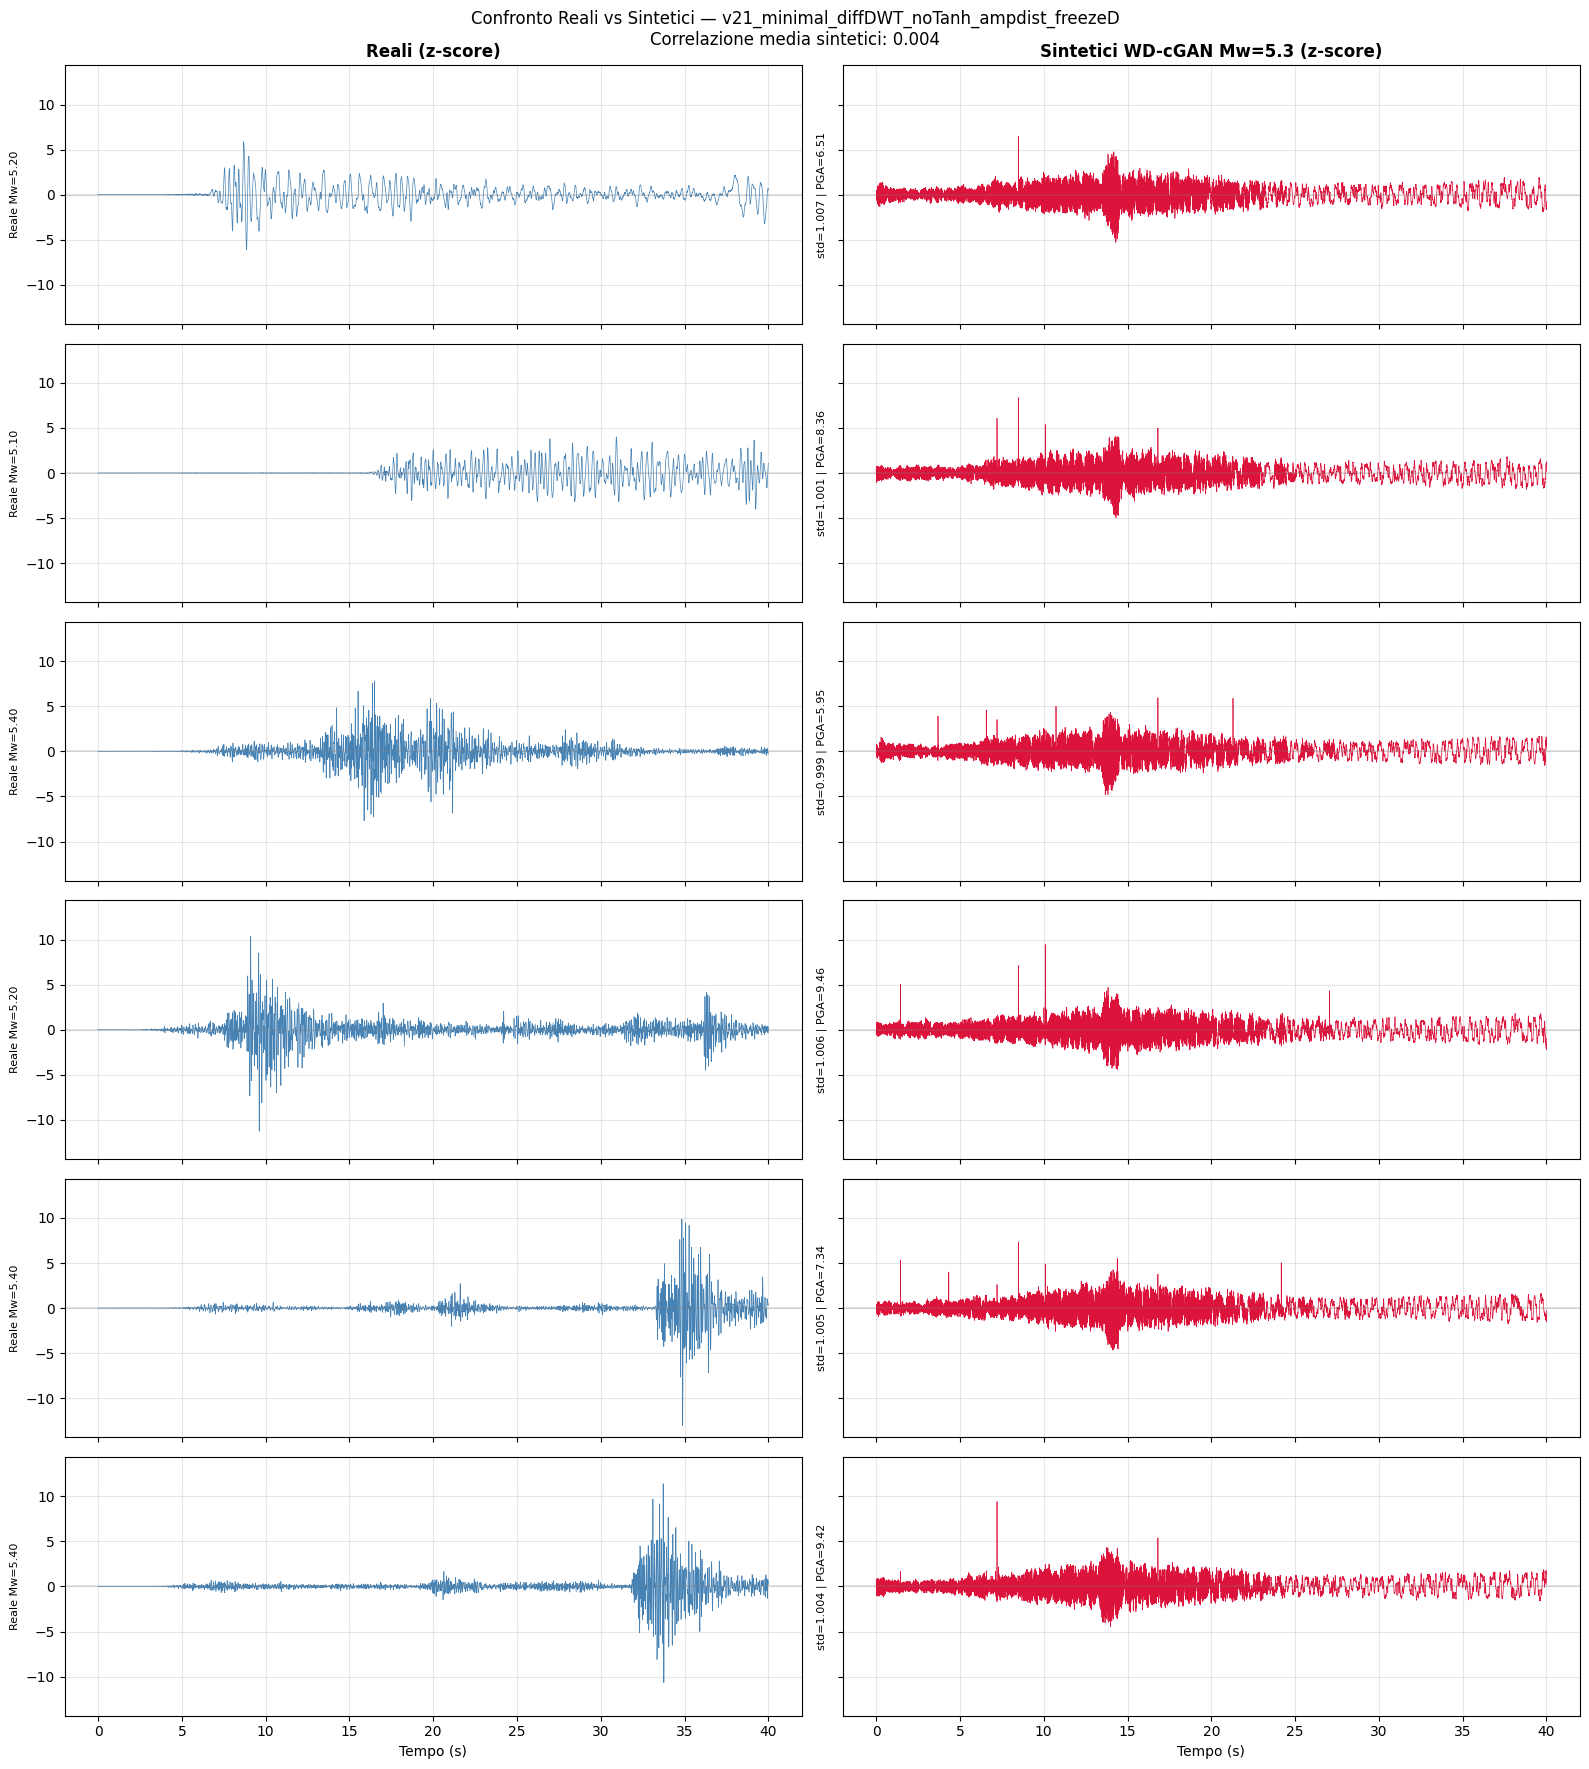

In [ ]:
# ============================================================
# Plot 1: Confronto 6 reali vs 6 sintetici
# ============================================================

y_max = max(np.max(np.abs(real_sel)), np.max(np.abs(sigs_synth))) * 1.1
fig, axes = plt.subplots(N_SHOW, 2, figsize=(16, 3 * N_SHOW))

for i in range(N_SHOW):
    axes[i, 0].plot(t, real_sel[i], lw=0.5, color='steelblue')
    axes[i, 0].set_ylim(-y_max, y_max)
    axes[i, 0].set_ylabel(f'Reale Mw={mags_sel[i]:.2f}', fontsize=8)
    axes[i, 0].axhline(0, color='gray', lw=0.3)
    axes[i, 0].grid(alpha=0.3)
    if i == 0:
        axes[i, 0].set_title('Reali (z-score)', fontweight='bold')
    if i < N_SHOW - 1:
        axes[i, 0].set_xticklabels([])

    axes[i, 1].plot(t, sigs_synth[i], lw=0.5, color='crimson')
    axes[i, 1].set_ylim(-y_max, y_max)
    axes[i, 1].set_yticklabels([])
    axes[i, 1].set_ylabel(
        f'std={sigs_synth[i].std():.3f} | PGA={np.max(np.abs(sigs_synth[i])):.2f}',
        fontsize=8
    )
    axes[i, 1].axhline(0, color='gray', lw=0.3)
    axes[i, 1].grid(alpha=0.3)
    if i == 0:
        axes[i, 1].set_title(f'Sintetici WD-cGAN Mw={MW_SHOW} (z-score)', fontweight='bold')
    if i < N_SHOW - 1:
        axes[i, 1].set_xticklabels([])

axes[-1, 0].set_xlabel('Tempo (s)')
axes[-1, 1].set_xlabel('Tempo (s)')
plt.suptitle(
    f'Confronto Reali vs Sintetici — {VERSION}\n'
    f'Correlazione media sintetici: {np.mean(cors):.3f}',
    fontsize=12
)
plt.tight_layout()
fig.savefig(os.path.join(LOG_DIR, f'confronto_reali_sintetici_{VERSION}.png'), dpi=150)
plt.show()


In [ ]:
# ============================================================
# Plot 2: Spettrogrammi
# ============================================================

fig, axes = plt.subplots(N_SHOW, 2, figsize=(16, 3 * N_SHOW))

for i in range(N_SHOW):
    for col, (sig, label, cmap) in enumerate([
        (real_sel[i],   f'Reale Mw={mags_sel[i]:.2f}', 'viridis'),
        (sigs_synth[i], f'Sint. std={sigs_synth[i].std():.3f}', 'inferno')
    ]):
        f_s, t_s, Sxx = sp_signal.spectrogram(sig, fs=FS, nperseg=256, noverlap=200)
        f_mask = f_s <= 25
        axes[i, col].pcolormesh(
            t_s,
            f_s[f_mask],
            10 * np.log10(Sxx[f_mask] + 1e-12),
            shading='gouraud',
            cmap=cmap,
            vmin=-60
        )
        axes[i, col].set_ylabel(label, fontsize=8)
        axes[i, col].set_ylim(0, 25)
        axes[i, col].grid(alpha=0.2, color='white', lw=0.3)
        if i < N_SHOW - 1:
            axes[i, col].set_xticklabels([])

    if i == 0:
        axes[i, 0].set_title('Spettrogramma Reali (dB)', fontweight='bold')
        axes[i, 1].set_title('Spettrogramma Sintetici (dB)', fontweight='bold')

axes[-1, 0].set_xlabel('Tempo (s)')
axes[-1, 1].set_xlabel('Tempo (s)')
plt.suptitle(f'Spettrogrammi Reali vs Sintetici (0-25 Hz) — {VERSION}', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(LOG_DIR, f'spettrogrammi_{VERSION}.png'), dpi=150)
plt.show()


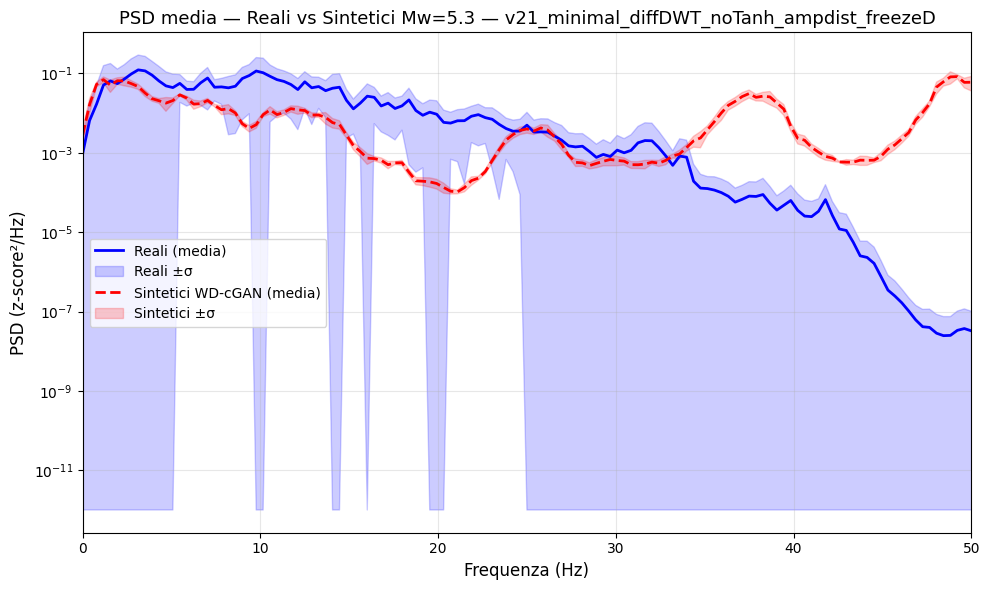

In [ ]:
# ============================================================
# Plot 3: PSD media
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

psd_r = np.array([sp_signal.welch(s, fs=FS, nperseg=512)[1] for s in real_sel])
psd_s = np.array([sp_signal.welch(s, fs=FS, nperseg=512)[1] for s in sigs_synth])
f_p, _ = sp_signal.welch(real_sel[0], fs=FS, nperseg=512)

mu_r = psd_r.mean(0)
sd_r = psd_r.std(0)
mu_s = psd_s.mean(0)
sd_s = psd_s.std(0)

ax.semilogy(f_p, mu_r, 'b-',  lw=2, label='Reali (media)')
ax.fill_between(f_p, np.clip(mu_r - sd_r, 1e-12, None), mu_r + sd_r,
                alpha=0.2, color='blue', label='Reali ±σ')
ax.semilogy(f_p, mu_s, 'r--', lw=2, label='Sintetici WD-cGAN (media)')
ax.fill_between(f_p, np.clip(mu_s - sd_s, 1e-12, None), mu_s + sd_s,
                alpha=0.2, color='red', label='Sintetici ±σ')

ax.set_xlabel('Frequenza (Hz)', fontsize=12)
ax.set_ylabel('PSD (z-score²/Hz)', fontsize=12)
ax.set_title(f'PSD media — Reali vs Sintetici Mw={MW_SHOW} — {VERSION}', fontsize=13)
ax.set_xlim(0, 50)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(LOG_DIR, f'psd_confronto_{VERSION}.png'), dpi=150)
plt.show()


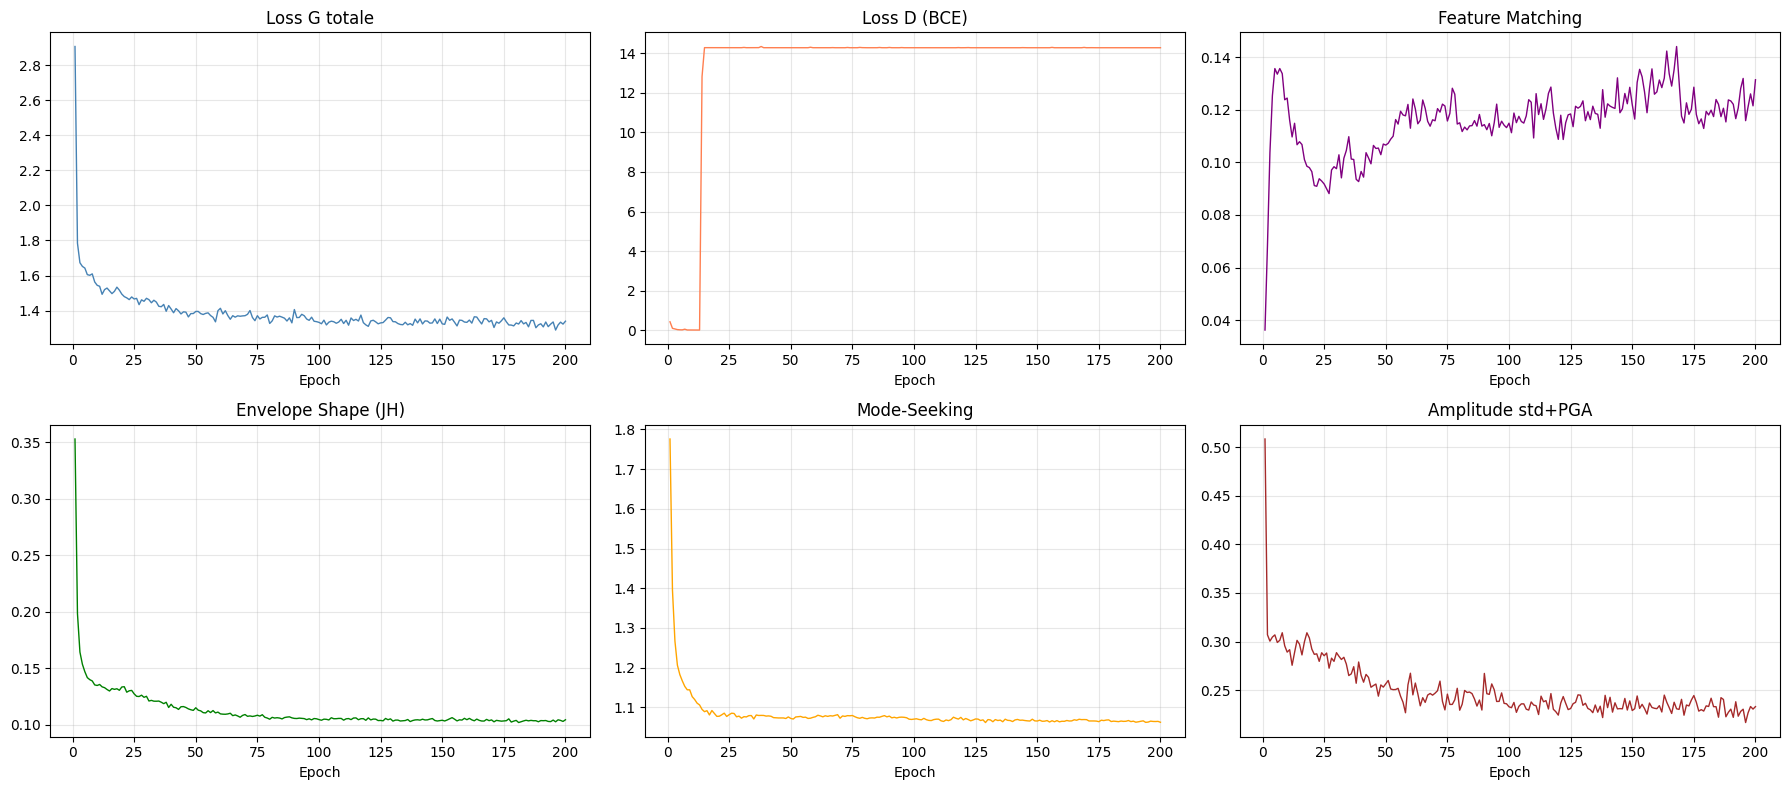

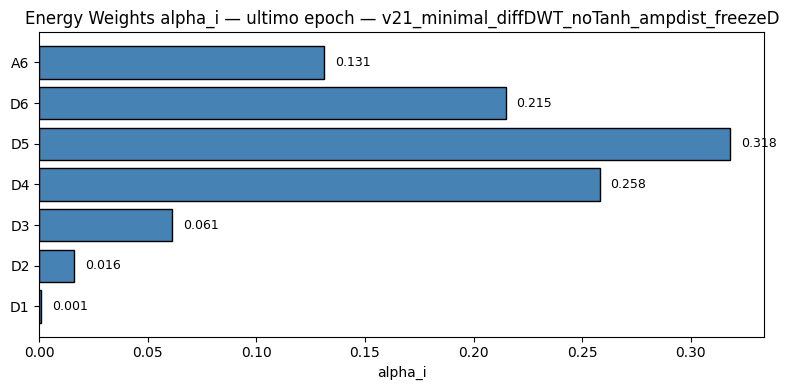

In [ ]:
# ============================================================
# Plot 4: Curve di loss
# ============================================================

ep_range = range(1, len(history['loss_G']) + 1)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for ax, (key, color, title) in zip(axes.flatten(), [
    ('loss_G',   'steelblue', 'Loss G totale'),
    ('loss_D',   'coral',     'Loss D (BCE)'),
    ('loss_fm',  'purple',    'Feature Matching'),
    ('loss_env', 'green',     'Envelope Shape (JH)'),
    ('loss_ms',  'orange',    'Mode-Seeking'),
    ('loss_amp', 'brown',     'Amplitude std+PGA'),
]):
    ax.plot(ep_range, history[key], color=color, lw=1)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(LOG_DIR, f'training_curves_{VERSION}.png'), dpi=150)
plt.show()

# Alpha finali
fa = history['alpha'][-1]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(band_names, fa, edgecolor='black', color='steelblue')
ax.set_xlabel('alpha_i')
ax.set_title(f'Energy Weights alpha_i — ultimo epoch — {VERSION}')
for i, v in enumerate(fa):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(LOG_DIR, f'alpha_weights_{VERSION}.png'), dpi=150)
plt.show()


In [ ]:
# ============================================================
# Salva modello finale
# ============================================================

final_path = os.path.join(BASE_DIR, f'wdcgan_final_{VERSION}.pt')

torch.save({
    'version': VERSION,
    'G_state': G.state_dict(),
    'cond_emb_state': cond_emb.state_dict(),
    'D_states': [d.state_dict() for d in discriminators],
    'band_lengths': band_lengths,
    'band_names': band_names,
    'history': history,
    'hparams': {
        'latent_dim': LATENT_DIM,
        'cond_dim': COND_DIM,
        'n_samples': N_SAMPLES,
        'dwt_wavelet': DWT_WAVELET,
        'dwt_level': DWT_LEVEL,
        'lr': LR,
        'beta1': BETA1,
        'beta2': BETA2,
        'mw_min': MW_MIN,
        'mw_max': MW_MAX,
        'lambda_fm': LAMBDA_FM,
        'lambda_env': LAMBDA_ENV,
        'lambda_amp': LAMBDA_AMP,
        'lambda_psd': LAMBDA_PSD,
        'lambda_ms': LAMBDA_MS,
        'psd_target': PSD_TARGET,
        'dropout': 0.1,
        'loss_G': 'FM_differentiable_DWT + L_env_JH_random + L_amp_std_PGA + L_psd + L_ms',
        'notes': 'DWT PyTorch differenziabile; no Tanh finale; D congelati nello step G.'
    }
}, final_path)

print(f'Modello salvato: {final_path}')


Modello salvato: /content/drive/MyDrive/WDcGAN/wdcgan_final_v21_minimal_diffDWT_noTanh_ampdist_freezeD.pt
